In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['figure.figsize'] = 12,6
plt.rcParams['font.size'] = 14
plt.rcParams['axes.unicode_minus'] = False

# 데이터 전처리 관련 ####################################################
# 결측치 처리
from sklearn.impute import SimpleImputer
# 표준화
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
# 인코더
from sklearn.preprocessing import LabelEncoder

# 학습 모델 성능 관련 ####################################################
# 원하는 비율로 데이터를 나누기 위해
from sklearn.model_selection import train_test_split
# K-Fold 교차 검증
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold
from sklearn.model_selection import StratifiedKFold
# 학습곡선
from sklearn.model_selection import learning_curve
# 하이퍼 파라미터 튜닝
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

# 모델 성능평가 #############################################
# 회귀용
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import root_mean_squared_error
# 분류용
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

from sklearn.metrics import roc_curve
from sklearn.metrics import auc
from sklearn.metrics import roc_auc_score
from sklearn.metrics import ConfusionMatrixDisplay

# 피처 선택 ################################################
from sklearn.feature_selection import VarianceThreshold
from sklearn.feature_selection import RFE
from sklearn.inspection import permutation_importance

# 학습모델 ##################################################
#분류
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from lightgbm import LGBMClassifier

#회귀
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from lightgbm import LGBMRegressor

# 결정트리를 시각화할 수 있는 라이브러리
from sklearn.tree import plot_tree

# 불필요한 경고 뜨지 않게
import warnings
warnings.filterwarnings('ignore')

### 분류

In [2]:
from sklearn.datasets import load_iris

iris = load_iris()
X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.3, stratify=y, random_state=42)

In [3]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [9]:
param_grid = {
    # 하나의 트리가 가질 수 있는 최대 리프 노드 수
    # 값이 크면 정확도가 높아진다. 너무 높으면 과적합이 발생한다.
    'num_leaves' : [7,15,31],
    # 트리의 최대 깊이 제한, 과적합 방지
    'max_depth' : [-1,5,10],
    # 학습률 : 낮을수록 정교하게 학습하지만 시간이 오래걸린다.
    'learning_rate' : [0.01,0.05,0.1],
    # 트리 개수
    'n_estimators' : [100,200,500],
    # 리프노드가 되기 위한 최소 데이터 수, 과적합 방지
    'min_child_samples' : [5,10,20],
    # 트리를 학습할 때 사용하는 데이터의 샘플링 비율
    # 1보다 작으면 트리마다 조금씩 다른 패턴의 데이터를 학습한다.
    'subsample' : [0.8,1.0]
}

In [10]:
model = LGBMClassifier(random_state=42, verbosity=-1, n_jobs=-1)
grid_search = GridSearchCV(model, param_grid = param_grid, cv=5)
grid_search.fit(X_train_scaled, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LGBMClassifie... verbosity=-1)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.01, 0.05, ...], 'max_depth': [-1, 5, ...], 'min_child_samples': [5, 10, ...], 'n_estimators': [100, 200, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fol

# 최적 모델 추출
best_lgbm = grid_search.best_estimator_
y_pred = best_lgbm.predict(X_test_scaled)
y_pred

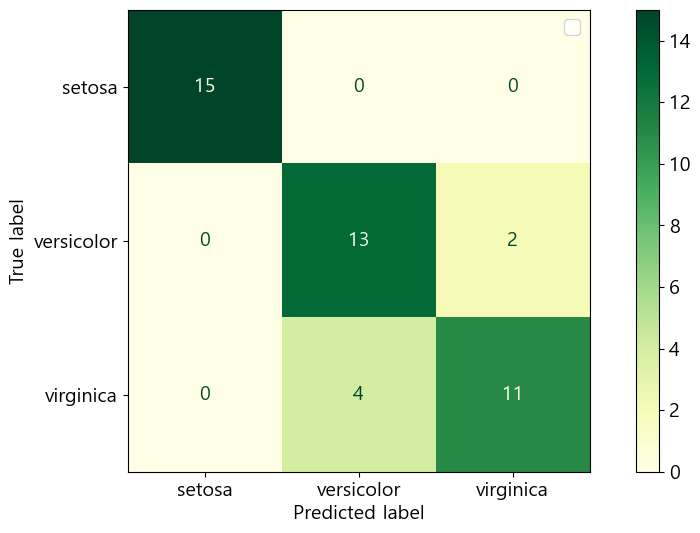

In [15]:
cm = confusion_matrix(y_test,y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=iris.target_names)
disp.plot(cmap=plt.cm.YlGn)
plt.legend()
plt.show()

In [18]:
# 평가지표
accuracy = accuracy_score(y_test,y_pred)
precision = precision_score(y_test,y_pred, average='macro')
recall = recall_score(y_test,y_pred, average='macro')
f1= f1_score(y_test,y_pred, average='macro')

print(f'최적의 파라미터 : {grid_search.best_params_}')
print(f'accuracy : {accuracy}')
print(f'precision : {precision}')
print(f'recall : {recall}')
print(f'f1 : {f1}')

최적의 파라미터 : {'learning_rate': 0.01, 'max_depth': -1, 'min_child_samples': 10, 'n_estimators': 100, 'num_leaves': 7, 'subsample': 0.8}
accuracy : 0.8666666666666667
precision : 0.8702865761689291
recall : 0.8666666666666667
f1 : 0.8660714285714285


### 회귀

In [20]:
from sklearn.datasets import load_diabetes

diabetes = load_diabetes()
X = diabetes.data
y = diabetes.target

X_train,X_test,y_train,y_test = train_test_split(X,y, test_size=0.3, random_state=42)

In [21]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [24]:
param_grid = {
    # 하나의 트리가 가질 수 있는 최대 리프 노드 수
    # 값이 크면 정확도가 높아진다. 너무 높으면 과적합이 발생한다.
    'num_leaves' : [15,31,50],
    # 트리의 최대 깊이 제한, 과적합 방지
    'max_depth' : [-1,10,20],
    # 학습률 : 낮을수록 정교하게 학습하지만 시간이 오래걸린다.
    'learning_rate' : [0.01,0.05,0.1],
    # 트리 개수
    'n_estimators' : [100,200,500],
    # 리프노드가 되기 위한 최소 데이터 수, 과적합 방지
    'min_child_samples' : [10,20,39],
    # 트리를 학습할 때 사용하는 데이터의 샘플링 비율
    # 1보다 작으면 트리마다 조금씩 다른 패턴의 데이터를 학습한다.
    'subsample' : [0.8,1.0]
}

In [25]:
model = LGBMRegressor(random_state=42, verbosity=-1, n_jobs=-1)
grid_search = GridSearchCV(model, param_grid=param_grid,cv=5)
grid_search.fit(X_train_scaled,y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LGBMRegressor... verbosity=-1)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.01, 0.05, ...], 'max_depth': [-1, 10, ...], 'min_child_samples': [10, 20, ...], 'n_estimators': [100, 200, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each f

In [28]:
best_lgbm = grid_search.best_estimator_
y_pred = best_lgbm.predict(X_test_scaled)
y_pred

array([164.62333386, 174.87356364, 147.88388893, 249.83168612,
       116.76631499,  91.52014247, 206.42172552, 180.8128982 ,
       131.2349755 , 150.29564985, 102.25116282, 188.92881413,
        97.11976424, 247.98305573,  92.85063519, 118.15658837,
       220.50683584, 275.9674447 , 214.76797858, 245.12374224,
       183.64980017,  88.49800781,  70.0782308 , 209.56594911,
       147.3013149 , 190.29734208, 203.2785236 , 182.05049438,
        82.28464855, 111.19434341, 161.06591864, 107.14407751,
       126.22495268, 195.87446938, 151.72308562, 232.12416192,
       105.1800834 , 111.58461369, 177.40347131,  67.78214229,
        76.61714793, 106.29342411, 182.02170694, 158.65355218,
       156.77139638,  73.23446871,  79.02372444, 119.47706907,
        80.9659225 , 148.46646265, 141.42430784,  70.52845449,
       143.07600249,  93.12278974, 189.87640835, 158.25416735,
        83.46483266, 219.36027105,  80.51168317,  97.96950947,
       181.57348646, 206.24109251, 143.39710121, 106.99

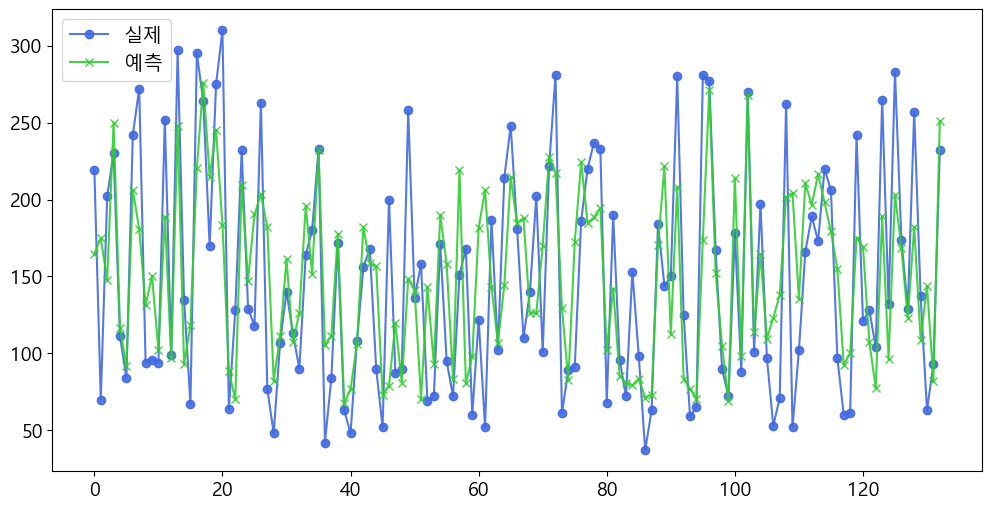

In [36]:
# 시각화
indices = np.arange(len(y_test))
plt.plot(indices, y_test, marker='o', label='실제', color='royalblue', alpha=0.9)
plt.plot(indices, y_pred, marker='x', label='예측', color='limegreen', alpha=0.9)
plt.legend()
plt.show()

In [40]:
# 평가지표 출력
mae = mean_absolute_error(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
rmse = root_mean_squared_error(y_test,y_pred)
r2 = best_lgbm.score(X_test_scaled,y_test)

print(f'최적 파라미터 : {grid_search.best_params_}')
print(f'mae : {mae:.4f}')
print(f'mse : {mse:.4f}')
print(f'rmse : {rmse:.4f}')
print(f'r2 : {r2:.4f}')

최적 파라미터 : {'learning_rate': 0.01, 'max_depth': -1, 'min_child_samples': 39, 'n_estimators': 500, 'num_leaves': 15, 'subsample': 0.8}
mae : 41.1405
mse : 2739.7081
rmse : 52.3422
r2 : 0.4925
